In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Датасет.

Датасет собран из строк песен ткаих реперов: ВитяАК, JahmalTGK, Ноганно.

3 класса:

1 - позитив

0 - негатив

2 - нейтраль

In [ ]:
sentiment_data = {
    "text": [
        # хорошо
        "Я поднялся с нуля теперь у меня есть всё",
        "Двигаюсь вперед и не смотрю назад",
        "Мы сделали это брат жизнь удалась",
        "Моя команда со мной мы на вершине",
        "Деньги пришли и жизнь стала лучше",
        "Я верил в себя и добился успеха",
        "Теперь все хотят быть рядом со мной",
        "Я выбрался из грязи и стал сильнее",
        "Мой путь был сложным но я победил",
        "Светит солнце и все идет как надо",

        # плохо
        "Вокруг одни проблемы и нет выхода",
        "Жизнь бьет по мне снова и снова",
        "Никто не верит и все против меня",
        "Деньги ушли и осталась пустота",
        "Я устал бороться и теряю силы",
        "Темные мысли не дают уснуть",
        "Все пошло не так как я хотел",
        "Друзья предали и я остался один",
        "Снова ошибки и снова боль",
        "Я потерял себя в этом мире",

        # нейтрально
        "Я иду по улице думаю о жизни",
        "Сижу на районе обычный день",
        "Смотрю в окно и считаю время",
        "Ночь сменяет день все как всегда",
        "Город живет своей жизнью",
        "Просто еду и слушаю музыку",
        "Сегодня обычный спокойный день",
        "Думаю о прошлом без эмоций",
    ],
    "sentiment": [
        1,1,1,1,1,1,1,1,1,1,
        0,0,0,0,0,0,0,0,0,0,
        2,2,2,2,2,2,2,2
    ]
}

df = pd.DataFrame(sentiment_data)

print("Размер датасета:", df.shape)
df.head()

Размер датасета: (28, 2)


,text,sentiment
0,Я поднялся с нуля теперь у меня есть всё,1
1,Двигаюсь вперед и не смотрю назад,1
2,Мы сделали это брат жизнь удалась,1
3,Моя команда со мной мы на вершине,1
4,Деньги пришли и жизнь стала лучше,1


## Преобразование текста и разбиение данных

Сначала я убираю нейтральные тексты, чтобы осталась бинарная классификация.

Далее переводим текст в числа при попмощи TF-IDF.

После этого:
- делю данные на обучающую и тестовую выборки
- масштабирую данные (Standardscaler), чтобы модель обучалась стабильнее

In [ ]:
# Берем только бинарную классификацию
df_binary = df[df["sentiment"] != 2].copy()

# TF-IDF
vectorizer = TfidfVectorizer(max_features=100, ngram_range=(1, 2))
X = vectorizer.fit_transform(df_binary["text"]).toarray()
y = df_binary["sentiment"].values

# train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# масштабирование
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Обуч выборка:", X_train.shape)
print("Тест выборка:", X_test.shape)

Обуч выборка: (14, 100)
Тест выборка: (6, 100)


## Создание модели

Используем keras.


- Dense слой (32 нейрона) — извлекает признаки
- ReLU — функция активации
- Dropout — отключает часть нейронов, чтобы избежать переобучения
- Dense слой (16 нейронов)
- ещё Dropout
- выходной слой (sigmoid) — дает вероятность (0 или 1)

Также задаем:
- loss = binary_crossentropy — функция ошибки
- optimizer = adam — алгоритм обучения

In [ ]:
model = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),

    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),

    layers.Dense(1, activation="sigmoid"),
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │         3,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

## Обучение модели

Используем Early Stopping:
он останавливает обучение, если модель перестает улучшаться.

Это помогает:
- не переобучиться
- не тратить лишнее время

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("Обучение завершено")

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 229ms/step - accuracy: 0.4545 - loss: 0.7243 - val_accuracy: 0.6667 - val_loss: 0.6603
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.4545 - loss: 0.7210 - val_accuracy: 0.6667 - val_loss: 0.6626
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5455 - loss: 0.6732 - val_accuracy: 0.6667 - val_loss: 0.6633
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5455 - loss: 0.7560 - val_accuracy: 0.6667 - val_loss: 0.6645
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.5455 - loss: 0.6947 - val_accuracy: 0.6667 - val_loss: 0.6628
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.7273 - loss: 0.5797 - val_accuracy: 0.6667 - val_loss: 0.6603
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4545 - loss: 0.6499 - val_accuracy: 0.6667 - val_loss: 0.6597
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.4545 - loss: 0.5945 - val_accuracy: 0.6667 - val_loss

## Графики

Loss - ошибка модели


Accuracy - точность

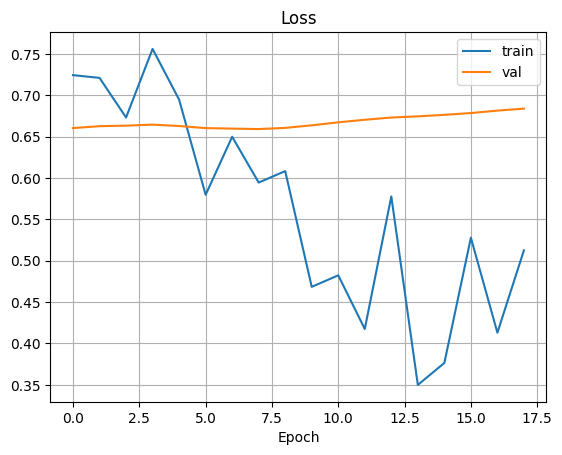

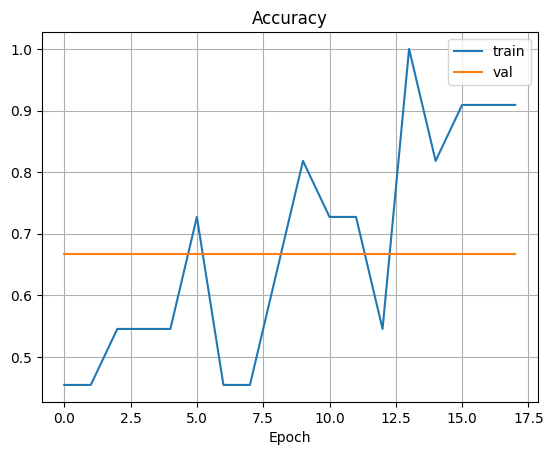

In [ ]:
plt.figure()
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()
plt.grid()
plt.show()